# Logistic Regression on CO2 Dataset
Predicting whether a car is a high CO2 emitter using fuel consumption.

## Load and clean the data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("co2.csv")

df["Model"] = df["Model"].str.strip().str.upper()
df["Make"] = df["Make"].str.strip().str.upper()
df = df.drop_duplicates().reset_index(drop=True)
df.columns = ["make", "model", "vclass", "engine", "cylinders", "trans", "fuel", "city", "hwy", "comb", "comb_mpg", "co2"]

print(df.shape)

(5990, 12)


**Observation:** 5,990 cars remain after removing duplicates.

## Create the yes/no column
A car is a high emitter (1) if its CO2 is above 250 g/km, otherwise 0.

In [12]:
df["high_co2"] = (df["co2"] > 250).astype(int)

print(df["high_co2"].value_counts())

high_co2
0    3165
1    2825
Name: count, dtype: int64


**Observation:** 3,165 cars are low emitters and 2,825 are high emitters, so the two groups are almost equal.

## Split into train and test

In [13]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

cut = int(len(df) * 0.8)
train = df[:cut].copy()
test = df[cut:].copy()

print("Training cars:", len(train))
print("Testing cars:", len(test))

Training cars: 4792
Testing cars: 1198


**Observation:** 4,792 cars are used for training and 1,198 for testing.

## Scale the input

In [14]:
mean = train["comb"].mean()
std = train["comb"].std()

x = (train["comb"] - mean)/std
y = train["high_co2"]

## The sigmoid function

In [15]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

## Train the model (gradient descent)

In [16]:
w = 0
b = 0
lr = 0.1
losses = []

for i in range(1000):
    p = sigmoid(w * x + b)

    loss = -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()
    losses.append(loss)

    dw = ((p - y) * x).mean()
    db = (p - y).mean()

    w = w - lr * dw
    b = b -lr * db

print("w:", round(w,3))
print("b:", round(b,3))
print("Loss at start:", round(losses[0],3))
print("Loss at end:", round(losses[-1],3))

w: 4.407
b: 0.293
Loss at start: 0.693
Loss at end: 0.227


**Observation:** The loss dropped from 0.693 to 0.227, so the model learned.

## Plot the loss

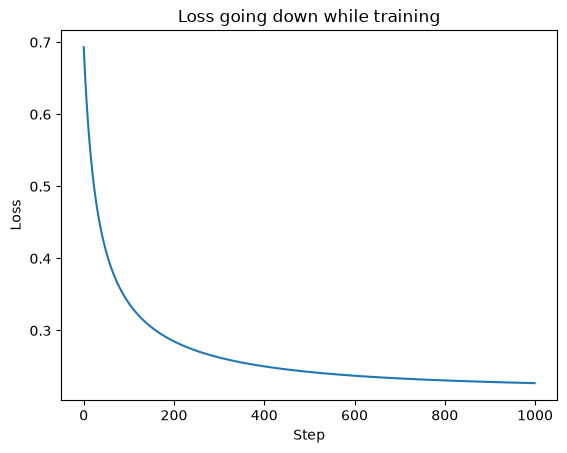

In [17]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss going down while training")
plt.show()

**Observation:** The loss falls quickly at first and then flattens, so the training worked.

## Predict on the test cars

In [18]:
x_test = (test["comb"] - mean) / std

test["probability"] = sigmoid(w * x_test + b)
test["prediction"] = (test["probability"] >= 0.5).astype(int)

test[["comb","co2","high_co2","probability","prediction"]].head(10)

,comb,co2,high_co2,probability,prediction
4792,10.2,238,0,0.263922,0
4793,8.9,208,0,0.049732,0
4794,9.2,215,0,0.075438,0
4795,8.0,188,0,0.013621,0
4796,9.5,218,0,0.112855,0
4797,9.6,221,0,0.128546,0
4798,10.7,249,0,0.429101,0
4799,18.0,288,1,0.999973,1
4800,14.8,340,1,0.996932,1
4801,7.0,164,0,0.003133,0


## Evaluate the model

In [23]:
accuracy = (test["prediction"] == test["high_co2"]).mean()

TP = ((test["prediction"] == 1) & (test["high_co2"] == 1)).sum()
TN = ((test["prediction"] == 0) & (test["high_co2"] == 0)).sum()
FP = ((test["prediction"] == 1) & (test["high_co2"] == 0)).sum()
FN = ((test["prediction"] == 0) & (test["high_co2"] == 1)).sum()

precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Accuracy:", round(accuracy * 100,1),"%")
print("Precision:", round(precision * 100, 3),"%")
print("Percentage of real high emitters the model found:", round(recall * 100,3),"%")
print()
print("Number of real high emitters the model correctly caught:", TP)
print("Number of real low emitters the model correctly caught:", TN)
print("Number of real low emmiters the model wrongly caught:", FP)
print("Numbers of real high emmiters the model wrongly caught:", FN)

Accuracy: 96.0 %
Precision: 97.872 %
Percentage of real high emitters the model found: 93.186 %

Number of real high emitters the model correctly caught: 506
Number of real low emitters the model correctly caught: 644
Number of real low emmiters the model wrongly caught: 11
Numbers of real high emmiters the model wrongly caught: 37


**Observation:** The model gets 96% of the test cars right.

## Plot the S-curve

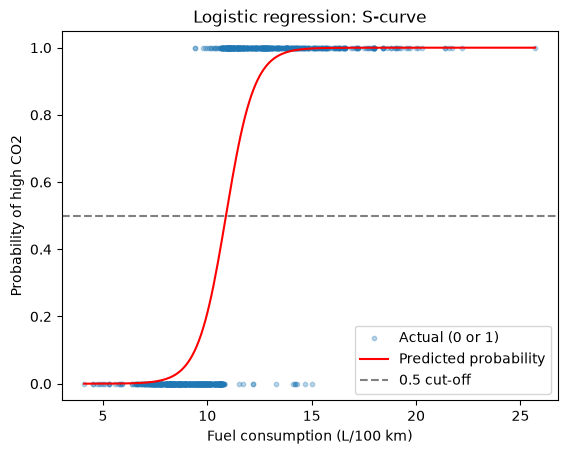

In [20]:
plt.scatter(test["comb"], test["high_co2"], s=10, alpha=0.3, label="Actual (0 or 1)")

order = test.sort_values("comb")
plt.plot(order["comb"], order["probability"], color="red", label="Predicted probability")

plt.axhline(0.5, color="gray", linestyle="--", label = "0.5 cut-off")
plt.xlabel("Fuel consumption (L/100 km)")
plt.ylabel("Probability of high CO2")
plt.title("Logistic regression: S-curve")
plt.legend()
plt.show()
 

**Observation:** Cars that use more fuel are more likely to be high emitters. The model switches from "low" to "high" at about 10.9 L/100 km.

## Conclusions
- Logistic regression was used to predict whether a car is a high CO2 emitter (above 250 g/km) using only fuel consumption.
- The model is 96% accurate on the test cars.
- When it predicts "high emitter", it is right about 98% of the time, and it finds 93% of the real high emitters.
- Cars using more than about 10.9 L/100 km are predicted to be high emitters.
- Most mistakes are cars close to the 250 g/km border or cars with unusual fuel types (diesel and ethanol).